In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

ROOT = "/content/drive/MyDrive/Colab Notebooks/GCP_Assignment_Datasets"

print(os.listdir(ROOT))

['train_dataset', 'test_dataset']


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/Colab Notebooks/GCP_Assignment_Datasets/train_dataset"
TEST_DIR = "/content/drive/MyDrive/Colab Notebooks/GCP_Assignment_Datasets/test_dataset"
JSON_PATH = "/content/drive/MyDrive/Colab Notebooks/GCP_Assignment_Datasets/train_dataset/gcp_marks.json"

#**1.Dataset inspection**

In [ ]:
import json

with open(JSON_PATH, "r") as f:
    labels = json.load(f)

print("Total labels:", len(labels))

# Print first sample
first_key = list(labels.keys())[0]
print("\nFirst image:")
print(first_key)

print("\nAnnotation:")
print(labels[first_key])

Total labels: 1000

First image:
scout_971/a61f66617a8dcf132dcc2cfa/GCP-11/DJI_20240301143538_0057_V.JPG

Annotation:
{'mark': {'x': 3272.769145523532, 'y': 1089.3292198344861}, 'verified_shape': 'Cross'}


#**2. Class distribution**

In [ ]:
first_image = list(labels.keys())[0]

print(labels[first_image])

{'mark': {'x': 3272.769145523532, 'y': 1089.3292198344861}, 'verified_shape': 'Cross'}


In [ ]:
for image_path in labels:
    if "verified_shape" not in labels[image_path]:
        print(image_path)
        print(labels[image_path])
        break

Seashell Ras el Hekma/Survey 3/GCP12/DJI_20240605112759_0254.JPG
{'mark': {'x': 2674.8615461670306, 'y': 427.01017187573916}}


#**3.Missing labels**

In [ ]:
shape_count = {}
missing_shape = 0

for image_path in labels:

    if "verified_shape" in labels[image_path]:

        shape = labels[image_path]["verified_shape"]

        if shape in shape_count:
            shape_count[shape] += 1
        else:
            shape_count[shape] = 1

    else:
        missing_shape += 1


print("Shape Distribution\n")

for shape in shape_count:
    print(shape, ":", shape_count[shape])

print("\nMissing Shape Labels :", missing_shape)

Shape Distribution

Cross : 177
Square : 328
L-Shape : 491

Missing Shape Labels : 4


#**4. Checking** whether all images mentioned in the JSON actually exist.

In [ ]:
import os

missing_images = 0

for image_path in labels:

    full_path = os.path.join(TRAIN_DIR, image_path)

    if not os.path.exists(full_path):
        print("Missing :", image_path)
        missing_images += 1

print("\nTotal Missing Images :", missing_images)


Total Missing Images : 0


#**5. Checking Image Sizes**

In [ ]:
import json

with open(JSON_PATH, "r") as file:
    labels = json.load(file)

print("Total Labels :", len(labels))

Total Labels : 1000


In [ ]:
from PIL import Image
import os

image_sizes = {}

count = 0

for image_path in labels:

    full_path = os.path.join(TRAIN_DIR, image_path)

    image = Image.open(full_path)

    width, height = image.size

    size = str(width) + " x " + str(height)

    if size in image_sizes:
        image_sizes[size] += 1
    else:
        image_sizes[size] = 1

    count += 1

    if count == 100:
        break


print("Image Sizes\n")

for size in image_sizes:
    print(size, ":", image_sizes[size])

Image Sizes

4096 x 3068 : 54
4096 x 2730 : 46


The dataset contains images with multiple resolutions (e.g., 4096×3068 and 4096×2730). Images will be resized to a fixed input size during preprocessing, and keypoint coordinates will be scaled accordingly

#**6. Visualize a few**

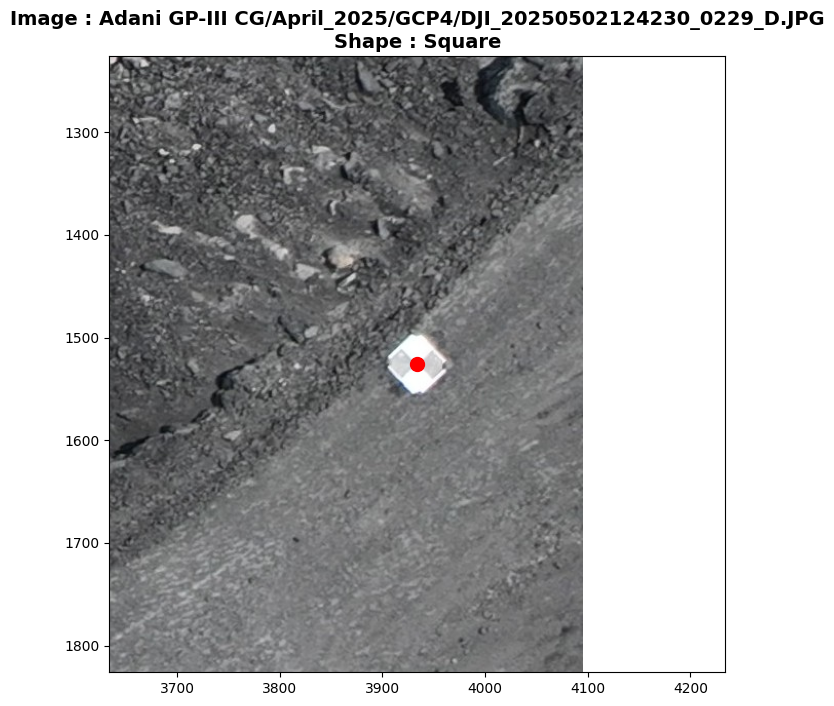

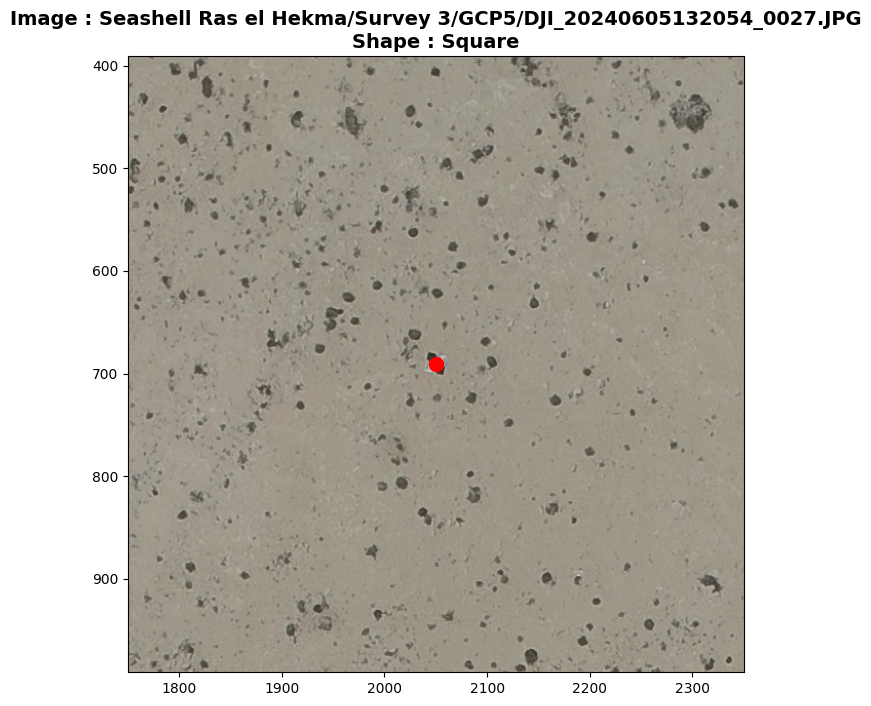

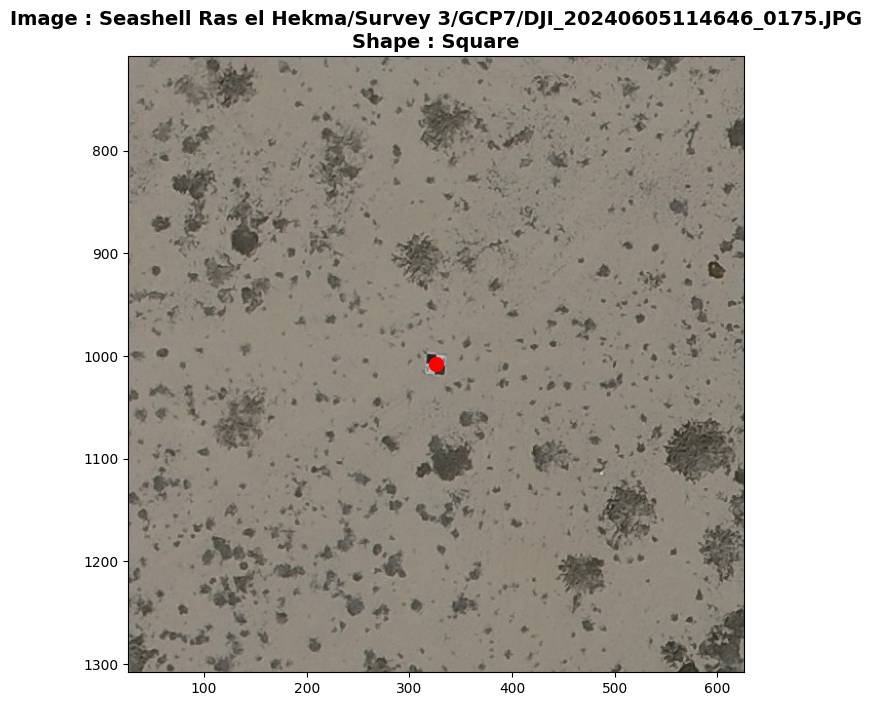

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

image_list = list(labels.keys())

for i in range(3):

    image_path = random.choice(image_list)

    full_path = os.path.join(TRAIN_DIR, image_path)

    image = Image.open(full_path)

    x = int(labels[image_path]["mark"]["x"])
    y = int(labels[image_path]["mark"]["y"])

    shape = "Not Available"

    if "verified_shape" in labels[image_path]:
        shape = labels[image_path]["verified_shape"]

    plt.figure(figsize=(8, 8))
    plt.imshow(image)

    plt.xlim(x - 300, x + 300)
    plt.ylim(y + 300, y - 300)

    plt.scatter(x, y, color="red", s=100)

    plt.title(
        f"Image : {image_path}\nShape : {shape}",
        fontsize=14,
        fontweight="bold"
    )

    plt.show()

#**7. any images are corrupted**

In [ ]:
from PIL import Image
import os

corrupted_images = 0

for image_path in labels:

    full_path = os.path.join(TRAIN_DIR, image_path)

    try:
        image = Image.open(full_path)
        image.verify()

    except:
        print("Corrupted Image :", image_path)
        corrupted_images += 1

print("\nTotal Corrupted Images :", corrupted_images)


Total Corrupted Images : 0


#**8. Check where the GCP points are located-spread across the image or mostly in one area.**

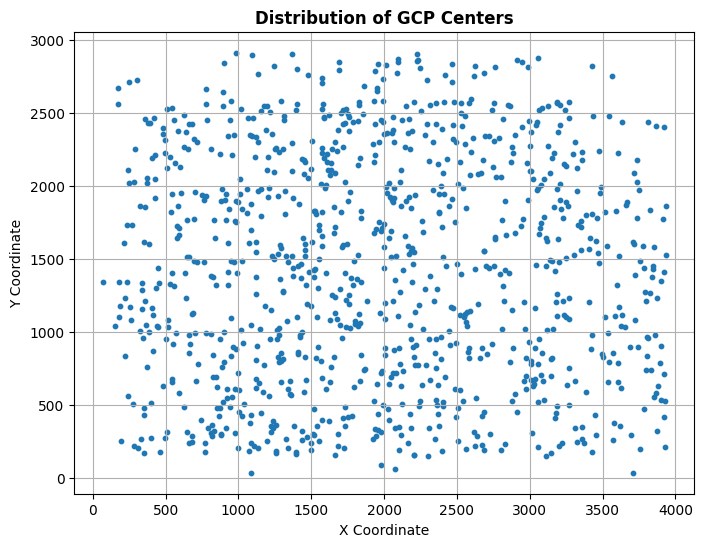

In [ ]:
import matplotlib.pyplot as plt

x_points = []
y_points = []

for image_path in labels:

    x = labels[image_path]["mark"]["x"]
    y = labels[image_path]["mark"]["y"]

    x_points.append(x)
    y_points.append(y)

plt.figure(figsize=(8,6))

plt.scatter(x_points, y_points, s=10)

plt.title("Distribution of GCP Centers", fontweight="bold")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.grid()

plt.show()

# **9.Check coordinate range** -make sure there are no invalid (x, y) values



In [ ]:
min_x = 100000
max_x = 0

min_y = 100000
max_y = 0

for image_path in labels:

    x = labels[image_path]["mark"]["x"]
    y = labels[image_path]["mark"]["y"]

    if x < min_x:
        min_x = x

    if x > max_x:
        max_x = x

    if y < min_y:
        min_y = y

    if y > max_y:
        max_y = y


print("Minimum X :", min_x)
print("Maximum X :", max_x)

print()

print("Minimum Y :", min_y)
print("Maximum Y :", max_y)

Minimum X : 66.96412957110547
Maximum X : 3937.0554836417386

Minimum Y : 35.044623574285524
Maximum Y : 2914.109404383081


# **what i did till now in EDA step**

1. Dataset inspection

2. Class distribution

3. Missing labels

4. Missing images

5. Image sizes

6. Visual verification

7. Corrupted image check

8. Coordinate distribution

9. Coordinate range

#**Data Preprocessing**

#**1: Create a Clean Dataset**

In [ ]:
dataset = []

for image_path in labels:

    if "verified_shape" not in labels[image_path]:
        continue

    data = {}

    data["image_path"] = os.path.join(TRAIN_DIR, image_path)

    data["x"] = labels[image_path]["mark"]["x"]

    data["y"] = labels[image_path]["mark"]["y"]

    data["shape"] = labels[image_path]["verified_shape"]

    dataset.append(data)

print("Total Training Samples :", len(dataset))

print("\nFirst Sample\n")

print("X Coordinate :", dataset[0]["x"])
print("Y Coordinate :", dataset[0]["y"])
print("Shape :", dataset[0]["shape"])

Total Training Samples : 996

First Sample

X Coordinate : 3272.769145523532
Y Coordinate : 1089.3292198344861
Shape : Cross


# **2. Convert Shape Labels to Number**

In [ ]:
shape_to_id = {
    "Cross": 0,
    "Square": 1,
    "L-Shape": 2
}

for data in dataset:

    data["label"] = shape_to_id[data["shape"]]

print("First Sample\n")

print("X Coordinate :", dataset[0]["x"])
print("Y Coordinate :", dataset[0]["y"])
print("Shape :", dataset[0]["shape"])
print("Label :", dataset[0]["label"])

First Sample

X Coordinate : 3272.769145523532
Y Coordinate : 1089.3292198344861
Shape : Cross
Label : 0


#**3: Spliting the Dataset**

In [ ]:
from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Samples :", len(train_data))
print("Validation Samples :", len(valid_data))

Training Samples : 796
Validation Samples : 200


#**4 :PyTorch part**

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
from torchvision import transforms

#**5: Create a Custom Dataset Class**

In [ ]:
class GCPDataset(Dataset):

    def __init__(self, data):

        self.data = data

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor()
        ])

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        sample = self.data[index]

        image = Image.open(sample["image_path"]).convert("RGB")

        image = self.transform(image)

        return image

#**6: Testing the Dataset**

In [ ]:

train_dataset = GCPDataset(train_data)

print("Total Images :", len(train_dataset))

image = train_dataset[0]

print("Image Shape :", image.shape)

Total Images : 796
Image Shape : torch.Size([3, 512, 512])


#**7: Return Image, Coordinates and Label**

In [ ]:
class GCPDataset(Dataset):

    def __init__(self, data):

        self.data = data

        self.transform = transforms.Compose([
        transforms.Resize((512, 512)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    def __len__(self):

        return len(self.data)

    def __getitem__(self, index):

        sample = self.data[index]

        image = Image.open(sample["image_path"]).convert("RGB")

        original_width, original_height = image.size

        image = self.transform(image)

        x = sample["x"] / original_width
        y = sample["y"] / original_height

        coordinates = torch.tensor([x, y], dtype=torch.float32)

        label = torch.tensor(sample["label"], dtype=torch.long)

        return image, coordinates, label

#**8: Test the Updated Dataset**

In [ ]:
train_dataset = GCPDataset(train_data)

image, coordinates, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Coordinates :", coordinates)
print("Label :", label)

Image Shape : torch.Size([3, 512, 512])
Coordinates : tensor([0.4015, 0.8261])
Label : tensor(2)


#**9: Create DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

train_dataset = GCPDataset(train_data)

valid_dataset = GCPDataset(valid_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

print("Train Batches :", len(train_loader))
print("Validation Batches :", len(valid_loader))

Train Batches : 50
Validation Batches : 13


In [ ]:
import torch
import torch.nn as nn

from torchvision import models

In [ ]:
class GCPModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = models.resnet18(weights="DEFAULT")

        self.backbone.fc = nn.Identity()

        self.regression_head = nn.Linear(512, 2)

        self.classification_head = nn.Linear(512, 3)

    def forward(self, image):

        features = self.backbone(image)

        coordinates = torch.sigmoid(
              self.regression_head(features)
        )

        shape = self.classification_head(features)

        return coordinates, shape

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GCPModel()

model = model.to(device)

print(model)

GCPModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_r

In [ ]:
train_dataset = GCPDataset(train_data)

image, coordinates, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Coordinates :", coordinates)
print("Label :", label)

Image Shape : torch.Size([3, 512, 512])
Coordinates : tensor([0.4015, 0.8261])
Label : tensor(2)


In [ ]:
coordinate_loss = nn.SmoothL1Loss()

classification_loss = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model is Ready for Training")

Model is Ready for Training


In [ ]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001,
    weight_decay=1e-4
)

In [ ]:
num_epochs = 20

best_loss = float("inf")

for epoch in range(num_epochs):

    model.train()

    total_loss = 0

    for batch, (images, coordinates, labels) in enumerate(train_loader):

        images = images.to(device)
        coordinates = coordinates.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        predicted_coordinates, predicted_labels = model(images)

        loss1 = coordinate_loss(predicted_coordinates, coordinates)

        loss2 = classification_loss(predicted_labels, labels)

        loss = loss1 + loss2

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


        if batch == 0:
            print(
                f"Epoch {epoch + 1} | "
                f"Coordinate Loss: {loss1.item():.4f} | "
                f"Classification Loss: {loss2.item():.4f} | "
                f"Total Loss: {loss.item():.4f}"
            )

    average_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{num_epochs} - Average Loss: {average_loss:.4f}")

    if average_loss < best_loss:

        best_loss = average_loss

        torch.save(model.state_dict(), "best_model.pth")

print("\nTraining Completed")

Epoch 1 | Coordinate Loss: 0.0379 | Classification Loss: 0.0096 | Total Loss: 0.0475
Epoch 1/20 - Average Loss: 0.1100
Epoch 2 | Coordinate Loss: 0.0371 | Classification Loss: 0.1509 | Total Loss: 0.1880
Epoch 2/20 - Average Loss: 0.0774
Epoch 3 | Coordinate Loss: 0.0321 | Classification Loss: 0.0237 | Total Loss: 0.0558
Epoch 3/20 - Average Loss: 0.0627
Epoch 4 | Coordinate Loss: 0.0170 | Classification Loss: 0.0074 | Total Loss: 0.0244
Epoch 4/20 - Average Loss: 0.0572
Epoch 5 | Coordinate Loss: 0.0250 | Classification Loss: 0.0046 | Total Loss: 0.0296
Epoch 5/20 - Average Loss: 0.0507
Epoch 6 | Coordinate Loss: 0.0265 | Classification Loss: 0.0047 | Total Loss: 0.0313
Epoch 6/20 - Average Loss: 0.0312
Epoch 7 | Coordinate Loss: 0.0191 | Classification Loss: 0.0020 | Total Loss: 0.0211
Epoch 7/20 - Average Loss: 0.0299
Epoch 8 | Coordinate Loss: 0.0232 | Classification Loss: 0.0019 | Total Loss: 0.0251
Epoch 8/20 - Average Loss: 0.0327
Epoch 9 | Coordinate Loss: 0.0245 | Classificati

KeyboardInterrupt: 

In [ ]:
import os

print("Model Exists :", os.path.exists("best_model.pth"))

Model Exists : True


In [ ]:
import shutil

shutil.copy(
    "best_model.pth",
    "/content/drive/MyDrive/best_model.pth"
)

print("Model Saved to Drive")

Model Saved to Drive


In [131]:
model = GCPModel().to(device)

model.load_state_dict(
    torch.load("best_model.pth", map_location=device)
)

model.eval()

print("Best Model Loaded Successfully")

Best Model Loaded Successfully


In [132]:
class TestDataset(Dataset):

    def __init__(self, test_dir):

        self.test_dir = test_dir

        self.images = []

        for root, _, files in os.walk(test_dir):

            for file in files:

                if file.lower().endswith((".jpg", ".jpeg", ".png")):

                    full_path = os.path.join(root, file)

                    relative_path = os.path.relpath(full_path, test_dir)

                    self.images.append((full_path, relative_path))

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):

        return len(self.images)

    def __getitem__(self, index):

        image_path, relative_path = self.images[index]

        image = Image.open(image_path).convert("RGB")

        original_width, original_height = image.size

        image = self.transform(image)

        return image, relative_path, original_width, original_height

In [133]:
test_dataset = TestDataset(TEST_DIR)

print("Total Test Images :", len(test_dataset))

image, path, width, height = test_dataset[0]

print("\nFirst Image")

print("Path :", path)
print("Original Width :", width)
print("Original Height :", height)
print("Image Shape :", image.shape)

Total Test Images : 300

First Image
Path : Amli Limestone Mine/MCDR_2024/GCP-78/DJI_20240414123637_0249_V.JPG
Original Width : 4096
Original Height : 3068
Image Shape : torch.Size([3, 512, 512])


In [134]:
test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Total Test Batches :", len(test_loader))

Total Test Batches : 19


In [135]:
import json

shape_names = {
    0: "Cross",
    1: "Square",
    2: "L-Shape"
}

predictions = {}

with torch.no_grad():

    for images, paths, widths, heights in test_loader:

        images = images.to(device)

        predicted_coordinates, predicted_labels = model(images)

        predicted_coordinates = predicted_coordinates.cpu().numpy()

        predicted_labels = torch.argmax(
            predicted_labels,
            dim=1
        ).cpu().numpy()

        for i in range(len(paths)):

            x = float(predicted_coordinates[i][0] * widths[i].item())
            y = float(predicted_coordinates[i][1] * heights[i].item())

            predictions[paths[i]] = {

                "mark": {

                    "x": x,
                    "y": y

                },

                "verified_shape": shape_names[
                    predicted_labels[i]
                ]
            }

with open("predictions.json", "w") as file:

    json.dump(
        predictions,
        file,
        indent=4
    )

print("Predictions Generated Successfully")
print("Total Predictions :", len(predictions))

Predictions Generated Successfully
Total Predictions : 300


In [136]:
with open("predictions.json", "r") as file:

    predictions = json.load(file)

print("Total Predictions :", len(predictions))

first_key = list(predictions.keys())[0]

print("\nFirst Prediction")

print(first_key)

print(predictions[first_key])

Total Predictions : 300

First Prediction
Amli Limestone Mine/MCDR_2024/GCP-78/DJI_20240414123637_0249_V.JPG
{'mark': {'x': 1987.271728515625, 'y': 2075.8271484375}, 'verified_shape': 'Square'}


In [137]:
import shutil

shutil.copy("predictions.json",
            "/content/drive/MyDrive/predictions.json")

shutil.copy("best_model.pth",
            "/content/drive/MyDrive/best_model.pth")

print("Files Saved Successfully")

Files Saved Successfully


In [143]:
readme = """
# Aerial GCP Pose Estimation

## About the Project

This project is my solution for the Computer Vision Engineering assignment.

The goal is to automatically find the center of a Ground Control Point (GCP) marker from aerial drone images and identify its shape.

The model performs two tasks:

- Predict the center (x, y) coordinates of the GCP marker.
- Classify the marker as Cross, Square or L-Shape.

---

## Dataset

Training Images: 996

Test Images: 300

The dataset contains aerial images collected from different survey locations. The images are organized in nested folders based on project, survey and GCP ID.

During EDA, I found that 4 training images were missing shape labels, so I excluded them from training.

---

## What I Did

Before training the model, I first explored the dataset.

I checked:

- Image sizes
- Shape distribution
- Missing labels
- Coordinate ranges
- Corrupted images
- Sample annotations

This helped me understand the dataset before building the model.

---

## Model

I used a pretrained ResNet18 as the backbone because it is lightweight and performs well for image feature extraction.

The model has two output heads:

- Regression head to predict the GCP coordinates.
- Classification head to predict the marker shape.

The coordinates were normalized during training and converted back to the original image size during inference.

---

## Training

Image size: 512 × 512

Image preprocessing:

- Resize
- ToTensor
- ImageNet Normalization

Loss Functions:

- SmoothL1Loss for coordinate prediction
- Weighted CrossEntropyLoss for shape classification

Optimizer:

- AdamW

Learning Rate:

0.0001

Training Epochs:

16

---

## Challenges

Some challenges I faced during this assignment were:

- Different image resolutions
- Missing shape labels
- Imbalanced classes
- Stable coordinate prediction

I handled these during preprocessing and model training.

---

## Output

The final model generates a `predictions.json` file in the same format as the training annotations.

It predicts:

- GCP center coordinates
- Marker shape

The trained model weights are saved as:

`best_model.pth`

---

## How to Run

1. Load the trained model.
2. Run the inference script on the test dataset.
3. The script generates `predictions.json`.

---

## Libraries Used

- Python
- PyTorch
- Torchvision
- NumPy
- Pillow

---
"""

with open("README.md", "w") as file:
    file.write(readme)

print("README.md created successfully.")

README.md created successfully.


In [144]:
import shutil

shutil.copy("README.md",
            "/content/drive/MyDrive/README.md")

print("README saved to Google Drive.")

README saved to Google Drive.


In [145]:
requirements = """
torch
torchvision
numpy
Pillow
matplotlib
tqdm
"""

with open("requirements.txt", "w") as file:
    file.write(requirements.strip())

print("requirements.txt created successfully.")

requirements.txt created successfully.


In [146]:
import shutil

shutil.copy(
    "requirements.txt",
    "/content/drive/MyDrive/requirements.txt"
)

print("requirements.txt saved successfully.")

requirements.txt saved successfully.
